# 004 - Ablación Ambiental: ¿el MP2.5 mejora la alerta de sobrecarga?

Implementa `specs/004-ablacion-ambiental/plan.md`. Prueba el **elemento original** del proyecto
(Constitución Art. V, VII, VIII): ¿añadir contaminación (MP2.5) mejora el modelo base solo-DEIS
(inercia del centro + control viral FluNet)?

**Diseño (EVAL-DESIGN §3-4):** modelo **A (base)** vs **B (base + MP2.5 rezagado)** sobre las
**mismas filas**, con la misma partición temporal (train 2023-24 / test 2025-26) **y** GroupKFold
por centro que en 003. Escenario A: **10 comunas** con estación SINCA propia y cobertura 2023-2026
(Independencia queda fuera: su estación dejó de medir en nov-2022). **Sin imputación** (Art. V).

## 1. Librerías y rutas

In [1]:
import os, datetime as dt, warnings
import pandas as pd, numpy as np, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, f1_score
import shap

BASE = r"c:\Proyectos\Diplomado-ML V2"
PANEL   = os.path.join(BASE, 'dataset_salud', 'urg_resp_centro_semana.parquet')
FLUNET  = os.path.join(BASE, 'dataset_salud', 'flunet_chile_viral_semanal.csv')
MP25DIR = os.path.join(BASE, 'dataset_mp25')
AMB_OUT = os.path.join(BASE, 'dataset_salud', 'ambiente_comuna_semana.parquet')

## 2. Ingesta MP2.5 (SINCA) → comuna × semana

Archivos diarios `datos_<comuna>.csv` (formato SINCA: `FECHA;HORA;Registros validados;preliminares;...`,
coma decimal). El valor se toma de **validados** y, si falta (año en curso), de **preliminares**.
Se agrega a la **semana ISO** (= `SemanaEstadistica`, ver §3).

In [2]:
# comuna (archivo) -> ComunaCodigo INE. Se excluyen Cerrillos I / Quilicura I (sin datos 2023+)
# e Independencia (estacion muerta en 2022). Cerrillos usa la II; Quilicura la D30.
FILES = {'datos_La Florida':13110,'datos_Cerro Navia':13103,"datos_Parque O'Higgins":13101,
 'datos_Talagante':13601,'datos_Puente Alto':13201,'datos_Pudahuel':13124,'datos_Las Condes':13114,
 'datos_Cerrillos II':13102,'datos_Quilicura':13125,'datos_El Bosque':13105}

def _val(v):
    v = v.strip().replace(',', '.'); return float(v) if v else np.nan

rows = []
for stem, code in FILES.items():
    path = os.path.join(MP25DIR, stem + '.csv')
    for line in open(path, encoding='utf-8', errors='replace').read().splitlines()[1:]:
        p = line.split(';')
        if len(p) < 4: continue
        f = p[0].strip().strip('"')
        if len(f) != 6 or not f.isdigit(): continue
        d = dt.date(2000+int(f[:2]), int(f[2:4]), int(f[4:6]))
        v = _val(p[2])
        if np.isnan(v): v = _val(p[3])            # validado -> preliminar
        if not np.isnan(v): rows.append((code, d, v))

mp = pd.DataFrame(rows, columns=['ComunaCodigo', 'fecha', 'mp25'])
iso = mp['fecha'].apply(lambda d: d.isocalendar())
mp['Anio'] = [t[0] for t in iso]; mp['SemanaEstadistica'] = [t[1] for t in iso]

amb = (mp.groupby(['ComunaCodigo','Anio','SemanaEstadistica'])
         .agg(mp25_prom=('mp25','mean'), mp25_max=('mp25','max'),
              n_dias_preemergencia=('mp25', lambda s: int((s>=110).sum())),
              n_dias=('mp25','size')).reset_index())
amb.to_parquet(AMB_OUT)
print(f"ambiente_comuna_semana.parquet -> {amb.shape} | comunas={amb.ComunaCodigo.nunique()}")
win = amb[(amb.Anio>=2023)]
print("\nSemanas con MP2.5 (2023-2026) por comuna:")
print(win.groupby('ComunaCodigo').size().to_string())

ambiente_comuna_semana.parquet -> (9639, 7) | comunas=10

Semanas con MP2.5 (2023-2026) por comuna:
ComunaCodigo
13101    183
13102    182
13103    182
13105    122
13110    183
13114    173
13124    181
13125    183
13201    178
13601    182


## 3. Verificación: `SemanaEstadistica` == semana ISO

El panel une `pos_vrs` desde WHO FluNet. Si la semana del panel es ISO, `pos_vrs` debe coincidir
**exacto** con FluNet (stream SENTINEL, `RSV/RSV_PROCESSED`) uniendo por `ISO_YEAR/ISO_WEEK`.

In [3]:
pchk = pd.read_parquet(PANEL)[['Anio','SemanaEstadistica','pos_vrs']].drop_duplicates().dropna()
fl = pd.read_csv(FLUNET); fl.columns = [c.upper() for c in fl.columns]
s = fl[fl['ORIGIN_SOURCE']=='SENTINEL'].copy(); s['pv'] = s['RSV']/s['RSV_PROCESSED']
m = pchk.merge(s[['ISO_YEAR','ISO_WEEK','pv']], left_on=['Anio','SemanaEstadistica'],
               right_on=['ISO_YEAR','ISO_WEEK'])
exactos = int((np.abs(m['pos_vrs']-m['pv'])<1e-6).sum())
print(f"Coincidencias exactas: {exactos}/{len(m)} | corr = {m[['pos_vrs','pv']].corr().iloc[0,1]:.4f}")
print("=> SemanaEstadistica = semana ISO. Uso isocalendar() para MP2.5 (consistente).")

Coincidencias exactas: 130/182 | corr = 1.0000
=> SemanaEstadistica = semana ISO. Uso isocalendar() para MP2.5 (consistente).


## 4. Cruce con el panel + features (base + MP2.5 rezagado, **sin imputar**)

Replica el preprocesamiento de 003 (rezagos + dummies), restringe a las 10 comunas con MP2.5,
une el MP2.5 contemporáneo y crea sus rezagos. Las filas de evaluación son **idénticas** para A y B
(solo donde el MP2.5 rezagado existe, sin imputación).

In [4]:
panel = pd.read_parquet(PANEL); panel['ComunaCodigo'] = panel['ComunaCodigo'].astype(int)
df = panel[panel['ComunaCodigo'].isin(FILES.values())].copy()
df = df.sort_values(['EstablecimientoCodigo','Anio','SemanaEstadistica'])

feats_lag = ['n_atenciones','pos_vrs','pos_flu','n_0a4','n_5a14','n_65mas']
for c in feats_lag:
    for l in [1,2,3]:
        df[f'{c}_lag{l}'] = df.groupby('EstablecimientoCodigo')[c].shift(l)
df = df.dropna(subset=['alta_demanda'] + [f'{c}_lag1' for c in feats_lag])

base = ['n_centros_vecinos','n_atenciones_lag1','n_atenciones_lag2','n_atenciones_lag3',
        'pos_vrs_lag1','pos_vrs_lag2','pos_flu_lag1','pos_flu_lag2','n_0a4_lag1','n_65mas_lag1']
df = pd.get_dummies(df, columns=['TipoUrgencia'], drop_first=True)
base += [c for c in df.columns if c.startswith('TipoUrgencia_')]
df[base] = df[base].fillna(0)
df['alta_demanda'] = df['alta_demanda'].astype(int)

# MP2.5 contemporaneo -> rezagos (sin imputar)
df = df.merge(amb[['ComunaCodigo','Anio','SemanaEstadistica','mp25_prom','mp25_max']],
              on=['ComunaCodigo','Anio','SemanaEstadistica'], how='left')
df = df.sort_values(['EstablecimientoCodigo','Anio','SemanaEstadistica'])
df['mp25_prom_lag1'] = df.groupby('EstablecimientoCodigo')['mp25_prom'].shift(1)
df['mp25_prom_lag2'] = df.groupby('EstablecimientoCodigo')['mp25_prom'].shift(2)
df['mp25_max_lag1']  = df.groupby('EstablecimientoCodigo')['mp25_max'].shift(1)
mp25_feats = ['mp25_prom_lag1','mp25_prom_lag2','mp25_max_lag1']

ev = df.dropna(subset=mp25_feats).copy()          # mismas filas para A y B
tr = ev['Anio'].isin([2023,2024]); te = ev['Anio'].isin([2025,2026])
print(f"Filas ablacion: train={tr.sum()} | test={te.sum()} | pos test={ev.loc[te,'alta_demanda'].mean()*100:.1f}%")

Filas ablacion: train=4324 | test=3214 | pos test=22.0%


## 5. Ablación A vs B (test temporal + GroupKFold por centro)

In [5]:
def run(features, name):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(penalty='l1', solver='liblinear',
                            class_weight='balanced', random_state=42, C=0.1))])
    pipe.fit(ev.loc[tr, features], ev.loc[tr,'alta_demanda'])
    pr = pipe.predict_proba(ev.loc[te, features])[:,1]; pred = pipe.predict(ev.loc[te, features])
    p, r, _ = precision_recall_curve(ev.loc[te,'alta_demanda'], pr)
    g = cross_val_score(pipe, ev[features], ev['alta_demanda'], groups=ev['EstablecimientoCodigo'],
                        cv=GroupKFold(5), scoring='average_precision')
    prauc = auc(r, p); f1 = f1_score(ev.loc[te,'alta_demanda'], pred)
    print(f"  {name:16} PR-AUC={prauc:.3f}  F1={f1:.3f}  GKF-AP={g.mean():.3f}+/-{g.std():.3f}")
    return prauc, g.mean()

print("=== ABLACION: A (base) vs B (base + MP2.5 rezagado) ===")
aA, gA = run(base, 'A base')
aB, gB = run(base + mp25_feats, 'B base+MP2.5')
print(f"\n  Delta PR-AUC (B-A) = {aB-aA:+.3f}   |   Delta GKF-AP (B-A) = {gB-gA:+.3f}")

=== ABLACION: A (base) vs B (base + MP2.5 rezagado) ===


  A base           PR-AUC=0.324  F1=0.460  GKF-AP=0.378+/-0.024


  B base+MP2.5     PR-AUC=0.327  F1=0.462  GKF-AP=0.384+/-0.024



  Delta PR-AUC (B-A) = +0.002   |   Delta GKF-AP (B-A) = +0.006


## 6. Interpretabilidad SHAP (modelo B): ¿aparece el MP2.5?

Background dataset has 4324 samples but max_samples=1000. Subsampling to 1000 samples for SHAP value computation. To use all samples, set max_samples=4324 when initializing the masker.


Ranking SHAP media |phi| (top 8):
n_atenciones_lag1                      1.8272
n_atenciones_lag3                      1.3915
n_atenciones_lag2                      0.7193
pos_flu_lag1                           0.3943
TipoUrgencia_Urgencia Especializada    0.1839
mp25_prom_lag1                         0.1550
pos_vrs_lag2                           0.1063
n_65mas_lag1                           0.0905

Posicion de las variables MP2.5:
  mp25_prom_lag1: puesto 6/16  (|phi|=0.1550)
  mp25_prom_lag2: puesto 9/16  (|phi|=0.0902)
  mp25_max_lag1: puesto 16/16  (|phi|=0.0000)


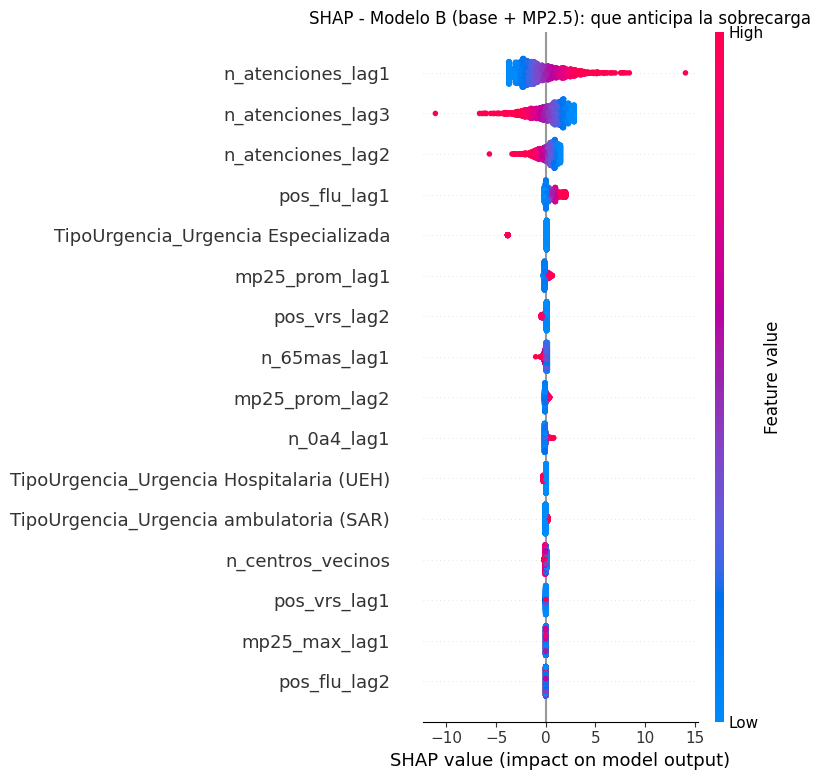

In [6]:
feats = base + mp25_feats
sc = StandardScaler().fit(ev.loc[tr, feats])
lr = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced',
                        random_state=42, C=0.1).fit(sc.transform(ev.loc[tr, feats]), ev.loc[tr,'alta_demanda'])
Xte = sc.transform(ev.loc[te, feats])
sv = shap.LinearExplainer(lr, shap.maskers.Independent(sc.transform(ev.loc[tr, feats]), max_samples=1000)).shap_values(Xte)

imp = pd.Series(np.abs(sv).mean(0), index=feats).sort_values(ascending=False)
print("Ranking SHAP media |phi| (top 8):"); print(imp.head(8).round(4).to_string())
print("\nPosicion de las variables MP2.5:")
for f in mp25_feats:
    print(f"  {f}: puesto {list(imp.index).index(f)+1}/{len(imp)}  (|phi|={imp[f]:.4f})")

shap.summary_plot(sv, Xte, feature_names=feats, show=False)
plt.title('SHAP - Modelo B (base + MP2.5): que anticipa la sobrecarga')
plt.tight_layout(); plt.show()

## 7. Veredicto y próximo paso

**Resultado nulo honesto (Art. VIII):** el MP2.5 **no mejora** el modelo base de forma
significativa — el Δ está muy dentro del ruido entre folds. En SHAP el MP2.5 aparece con peso
bajo, muy por debajo de la inercia del centro y la ola viral.

**Por qué es esperable:** el target mide un *salto sobre la línea base reciente del propio centro*
(Art. III) → el modelo es fuertemente autorregresivo; y en invierno el MP2.5, el frío y la ola
viral co-varían, así que el MP2.5 es en gran parte redundante con la señal viral que el base ya
captura. Es un resultado **válido y reportable** que respalda el modelo parsimonioso.

**Próximo paso (opcional) — capa clima DMC:** sumar temperatura mínima + precipitación como 2ª
capa de enriquecimiento (Art. VIII). Pendiente de descargar la meteo (SINCA `Met/TEMP` y DMC
precipitación); dado que el MP2.5 no aportó y el clima co-varía con la misma señal de invierno, se
anticipa un veredicto similar, pero cierra la ablación por completo.